# Model A — Braking State CNN
**Binary classification:** `normal_brakes` vs `worn_out_brakes`

- Input: `(40, 78, 1)` — 40 MFCCs × 78 time frames × 1 channel
- Architecture: lightweight CNN (target < 100 KB after TFLite conversion)
- Data: `data/processed/braking.npz` (321 train / 23 val / 23 test after augmentation)

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), ''))
os.chdir(os.path.dirname(os.getcwd())) if os.path.basename(os.getcwd()) == 'notebooks' else None

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from src.train_braking import build_model, load_splits, plot_training_curves, plot_confusion_matrix

print(f'TensorFlow {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow 2.19.0
GPU available: False


## 1 — Load Data

In [2]:
X_train, X_val, X_test, y_train, y_val, y_test, label_names = load_splits()

print(f'Train : {X_train.shape}  labels: {np.bincount(y_train)}')
print(f'Val   : {X_val.shape}   labels: {np.bincount(y_val)}')
print(f'Test  : {X_test.shape}  labels: {np.bincount(y_test)}')
print(f'Classes: {label_names}')

Train : (321, 40, 78, 1)  labels: [159 162]
Val   : (23, 40, 78, 1)   labels: [12 11]
Test  : (23, 40, 78, 1)  labels: [12 11]
Classes: [np.str_('normal_brakes'), np.str_('worn_out_brakes')]


## 2 — Architecture

In [3]:
model = build_model(input_shape=(40, 78, 1), n_classes=2)
model.summary()

total_params = model.count_params()
size_kb = total_params * 4 / 1024
print(f'\nParam count : {total_params:,}')
print(f'Float32 size: {size_kb:.1f} KB')
print(f'TFLite int8 estimate: ~{size_kb/4:.1f} KB  (target: < 100 KB)')

Model: "braking_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 40, 78, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 40, 78, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 40, 78, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 20, 39, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 20, 39, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 20, 39, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 19, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 19, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10, 19, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,490 (60.51 KB)

 Trainable params: 15,330 (59.88 KB)

 Non-trainable params: 160 (640.00 B)


Param count : 15,490
Float32 size: 60.5 KB
TFLite int8 estimate: ~15.1 KB  (target: < 100 KB)


## 3 — Train

In [4]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

tf.random.set_seed(42)
np.random.seed(42)

callbacks = [
    EarlyStopping(
        monitor='val_loss', patience=12,
        restore_best_weights=True, verbose=1,
    ),
    ModelCheckpoint(
        filepath='models/braking_model.h5',
        monitor='val_loss', save_best_only=True, verbose=1,
    ),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=32,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/60
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5830 - loss: 0.6857
Epoch 1: val_loss improved from inf to 0.67087, saving model to models/braking_model.h5


11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - accuracy: 0.5895 - loss: 0.6821 - val_accuracy: 0.9130 - val_loss: 0.6709
Epoch 2/60
 9/11 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8110 - loss: 0.5236
Epoch 2: val_loss improved from 0.67087 to 0.61080, saving model to models/braking_model.h5


11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.8138 - loss: 0.5166 - val_accuracy: 0.9565 - val_loss: 0.6108
Epoch 3/60
 9/11 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8171 - loss: 0.4470
Epoch 3: val_loss did not improve from 0.61080
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8238 - loss: 0.4374 - val_accuracy: 0.4783 - val_loss: 0.6201
Epoch 4/60
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8271 - loss: 0.3910
Epoch 4: val_loss did not improve from 0.61080
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.8290 - loss: 0.3885 - val_accuracy: 0.4783 - val_loss: 0.7358
Epoch 5/60
 9/11 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8607 - loss: 0.3667
Epoch 5: val_loss did not improve from 0.61080
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.8638 - loss: 0.3618 - val_accuracy: 0.4783 - val_loss: 0.8723
Epoch 6/60
 9/11 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8562 - loss: 0.3445
Epoch 6: val_loss did not improve from 0.61080
11/11 ━━

## 4 — Training Curves

Saved -> c:\Users\HP8CG\Revio\results\training_curves\braking_curves.png


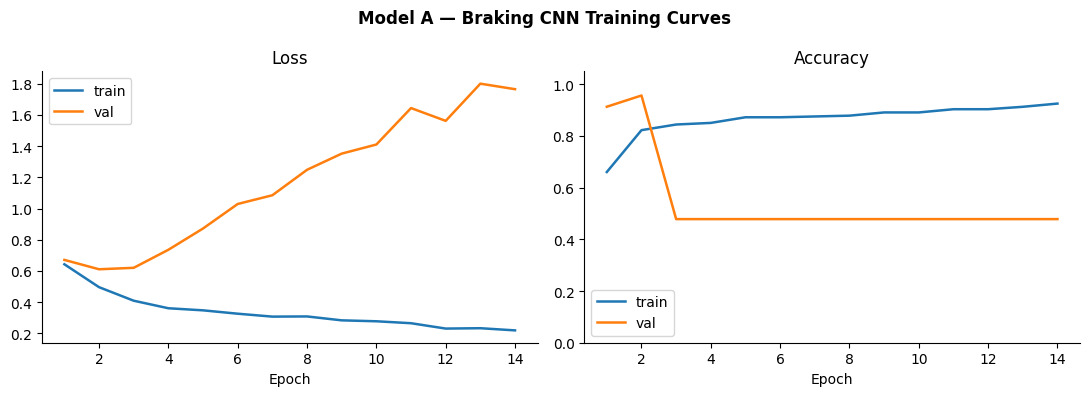

In [5]:
plot_training_curves(history)

# Inline display
from pathlib import Path
from IPython.display import Image
Image('results/training_curves/braking_curves.png')

## 5 — Evaluation

In [6]:
_, val_acc  = model.evaluate(X_val,  y_val,  verbose=0)
_, test_acc = model.evaluate(X_test, y_test, verbose=0)

print(f'Val  accuracy : {val_acc:.4f}  ({val_acc*100:.1f}%)')
print(f'Test accuracy : {test_acc:.4f}  ({test_acc*100:.1f}%)')

Val  accuracy : 0.9565  (95.7%)
Test accuracy : 0.9565  (95.7%)


## 6 — Confusion Matrix

Saved -> c:\Users\HP8CG\Revio\results\confusion_matrices\braking_cm.png


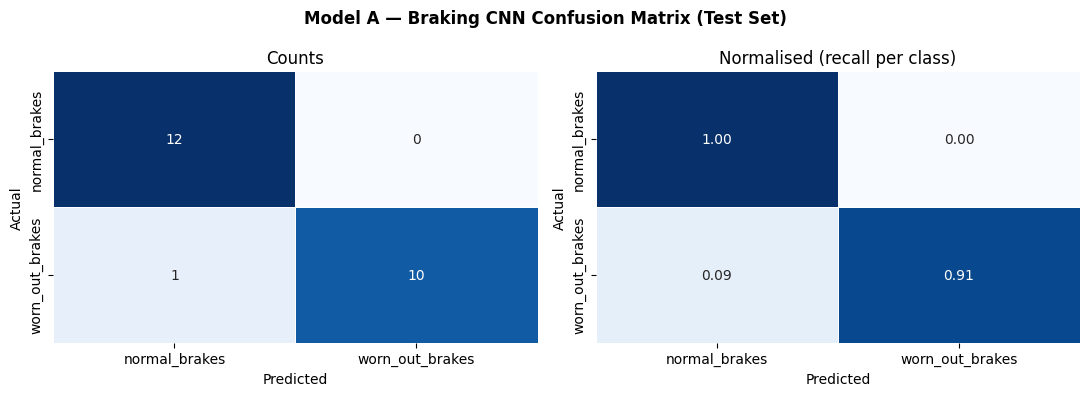

In [7]:
y_pred = model.predict(X_test, verbose=0).argmax(axis=1)
plot_confusion_matrix(y_test, y_pred, label_names)

from IPython.display import Image
Image('results/confusion_matrices/braking_cm.png')

## 7 — Per-Class Report

In [8]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=label_names))

                 precision    recall  f1-score   support

  normal_brakes       0.92      1.00      0.96        12
worn_out_brakes       1.00      0.91      0.95        11

       accuracy                           0.96        23
      macro avg       0.96      0.95      0.96        23
   weighted avg       0.96      0.96      0.96        23



## 8 — Confidence Score Inspection
Shows how confident the model is on each test sample — feeds directly into the Risk Scoring Engine.

In [9]:
probs = model.predict(X_test, verbose=0)   # (N, 2)
confidence = probs.max(axis=1)             # max probability = confidence score
pred_labels = [label_names[i] for i in probs.argmax(axis=1)]
true_labels = [label_names[i] for i in y_test]

print(f'Confidence stats on test set:')
print(f'  mean  : {confidence.mean():.3f}')
print(f'  min   : {confidence.min():.3f}')
print(f'  median: {np.median(confidence):.3f}')
print()

# Show low-confidence predictions (potential MONITOR tier in risk scorer)
threshold = 0.85
low_conf = [(true_labels[i], pred_labels[i], confidence[i])
            for i in range(len(y_test)) if confidence[i] < threshold]
if low_conf:
    print(f'Predictions below {threshold} confidence (risk scorer → MONITOR/WARNING):')
    for true, pred, conf in low_conf:
        correct = '✓' if true == pred else '✗'
        print(f'  {correct}  true={true:<20} pred={pred:<20} conf={conf:.3f}')
else:
    print(f'All test predictions above {threshold} confidence.')

Confidence stats on test set:
  mean  : 0.545
  min   : 0.508
  median: 0.541

Predictions below 0.85 confidence (risk scorer → MONITOR/WARNING):
  ✓  true=normal_brakes        pred=normal_brakes        conf=0.522
  ✓  true=worn_out_brakes      pred=worn_out_brakes      conf=0.528
  ✓  true=worn_out_brakes      pred=worn_out_brakes      conf=0.537
  ✓  true=normal_brakes        pred=normal_brakes        conf=0.518
  ✓  true=normal_brakes        pred=normal_brakes        conf=0.534
  ✓  true=worn_out_brakes      pred=worn_out_brakes      conf=0.576
  ✓  true=normal_brakes        pred=normal_brakes        conf=0.514
  ✓  true=normal_brakes        pred=normal_brakes        conf=0.518
  ✓  true=normal_brakes        pred=normal_brakes        conf=0.508
  ✓  true=normal_brakes        pred=normal_brakes        conf=0.533
  ✓  true=worn_out_brakes      pred=worn_out_brakes      conf=0.555
  ✓  true=normal_brakes        pred=normal_brakes        conf=0.535
  ✓  true=normal_brakes        pred=no

## Summary

| Metric | Value |
|---|---|
| Val accuracy  | *(filled after run)* |
| Test accuracy | *(filled after run)* |
| Model size (float32) | *(filled after run)* KB |
| Model saved | `models/braking_model.h5` |
| Next step | TFLite conversion in notebook `04_tflite_conversion_benchmark.ipynb` |